In [1]:
import pandas as pd
import os

In [2]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_metrics"

In [3]:
dfs = []
for f in os.listdir(file_dir):
    if "df_calibration" in f:
        continue
    df = pd.read_csv(os.path.join(file_dir, f), index_col=0)
    df["reg"] = f.split("_")[-1].strip(".csv")
    dfs.append(df) 

df = pd.concat(dfs, axis=0)

In [4]:
df_stoch = df[df["reg"]=="0.1"]

In [ ]:
df_stoch["donor_cytokine"] = df_stoch.index
df_stoch["donor"] = df_stoch.apply(lambda x: x["donor_cytokine"].split("_")[0], axis=1)
df_stoch["cytokine"] = df_stoch.apply(lambda x: x["donor_cytokine"].split("_")[1], axis=1)

In [37]:
df_other = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv")
df_other = df_other[df_other['num_donors_in_train']==0]

/tmp/ipykernel_900549/3746172922.py:1: DtypeWarning: Columns (1,128,129,171) have mixed types. Specify dtype option on import or set low_memory=False.
  df_other = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv")


In [46]:
df_other["mean_ood_e_distance"] = df_other["ood_e_distance"]
df_other["mean_deg_r"] = df_other['mean_deg_r_sq_per_cell_type']

In [47]:
df_stoch["method"] = "cf_stoch"
df = pd.concat((df_stoch, df_cf))
df = pd.concat((df_stoch, df_other))

In [48]:
df["method"].value_counts()

method
cf_stoch    144
cf          144
id          144
m1          144
cl          144
Name: count, dtype: int64

In [49]:
df.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine_with_stochastic.csv")

<Axes: xlabel='method', ylabel='mean_ood_e_distance'>

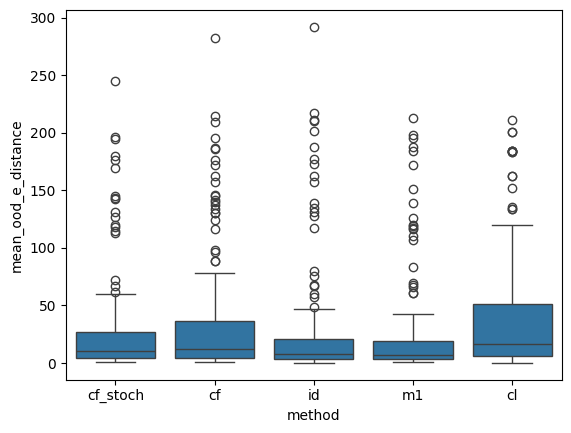

In [44]:
import seaborn as sns
sns.boxplot(df, y="mean_ood_e_distance", x="method")

<Axes: xlabel='method', ylabel='mean_deg_r_sq_per_cell_type'>

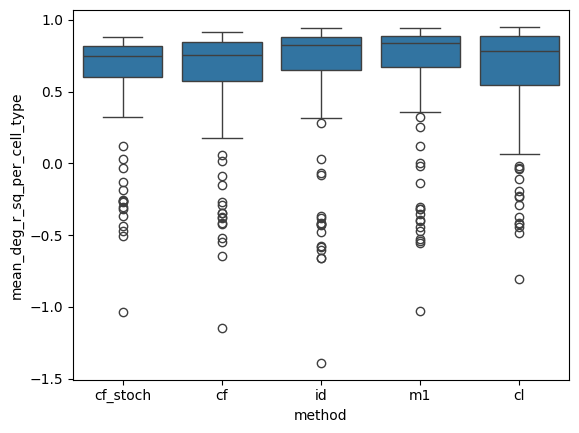

In [45]:
sns.boxplot(df, y="mean_deg_r_sq_per_cell_type", x="method")